# B18 Receiver Calibration

### Parameters

In [1]:
outpath: str = "."
alandir: str = "/data4/smurray/edges/alans-pipeline/scripts/"
calobsdir: str = "/data5/edges/data/CalibrationObservations/Receiver01/Receiver01_25C_2015_09_02_040_to_200MHz"

In [2]:
# Parameters
outpath = "."


## The Comparisons

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from edges.alanmode import read_spec_txt, read_specal, Edges2CalobsParams, EdgesScriptParams, ACQPlot7aMoonParams, LOADMAP
from edges.alanmode.cli import alancal_edges2, AlanCalOpts
from edges.data import fetch_b18cal_calibrated_s11s

In [4]:
def read_s11m(pth):
    _s11m = np.genfromtxt(pth, comments="#", names=True)
    s11m = {}
    freq = _s11m["freq"]
    for name in _s11m.dtype.names:
        if name == "freq":
            continue

        bits = name.split("_")
        cmp = bits[-1]
        load = "_".join(bits[:-1])

        if load not in s11m:
            s11m[load] = np.zeros(len(_s11m), dtype=complex)
        if cmp == "real":
            s11m[load] += _s11m[name]
        else:
            s11m[load] += _s11m[name] * 1j

    return freq, pd.DataFrame(s11m)

In [5]:
outpath = Path(outpath)
if not outpath.exists():
    outpath.mkdir()

## Run the Calibration

In [6]:
SPEC=Path(calobsdir)/"Spectra"

acq= ACQPlot7aMoonParams(
    fstart=40.0,
    fstop=110.0,
    delaystart=7200,
)

res =alancal_edges2(
    data = Edges2CalobsParams(
        s11_path = fetch_b18cal_calibrated_s11s(),
        ambient_acqs=sorted(SPEC.glob("Ambient_*.acq")),
        hotload_acqs=sorted(SPEC.glob("HotLoad_*.acq")),
        open_acqs=sorted(SPEC.glob("LongCableOpen_*.acq")),
        short_acqs=sorted(SPEC.glob("LongCableShorted_*.acq")),
    ),
    opts = AlanCalOpts(
        avg = acq,
        cal = EdgesScriptParams(
            wfstart=50.0,
            wfstop=100.0,
            Lh=-2,
            tcold=296,
            thot=399,
            cfit=6,
            wfit=5,        
            nfit2=27,
            nfit3=11,
            lna_poly=0,
        ),
        plot=False,
        out=outpath,
        redo_spectra=False,
        redo_cal=True
    )
)

Reading Ambient_01_2015_245_02_00_00_lab.acq: 0lines [00:00, ?lines/s]

Reading Ambient_01_2015_245_02_00_00_lab.acq: 46lines [00:00, 452.37lines/s]

Reading Ambient_01_2015_245_02_00_00_lab.acq: 92lines [00:00, 420.34lines/s]

Reading Ambient_01_2015_245_02_00_00_lab.acq: 145lines [00:00, 466.69lines/s]

Reading Ambient_01_2015_245_02_00_00_lab.acq: 196lines [00:00, 458.69lines/s]

...

Reading LongCableShorted_01_2015_243_00_00_00_lab.acq: 3959lines [00:06, 596.84lines/s]

Saving modelled S11s

Saving hot-load loss model

Saving calibrated temperatures

Saving known load temperatures

### Check Modelling of S11's

In [7]:
alancalfreq, alans11m = read_s11m(f"{alandir}/H2Case/s11_modelled.txt")
alancalfreq, alans11m_fixtp = read_s11m(f"{alandir}/H2Case-fittpfix/s11_modelled.txt")

calfreq, ours11m = read_s11m(outpath / "s11_modelled.txt")

In [8]:
alanmask = (alancalfreq >= 50.0) & (alancalfreq <= 100.0)

In [9]:
alans11m = alans11m[alanmask]
alans11m_fixtp = alans11m_fixtp[alanmask]

In [10]:
alan_s11m_cases = {"With fittp() fix": alans11m_fixtp, "Original": alans11m}

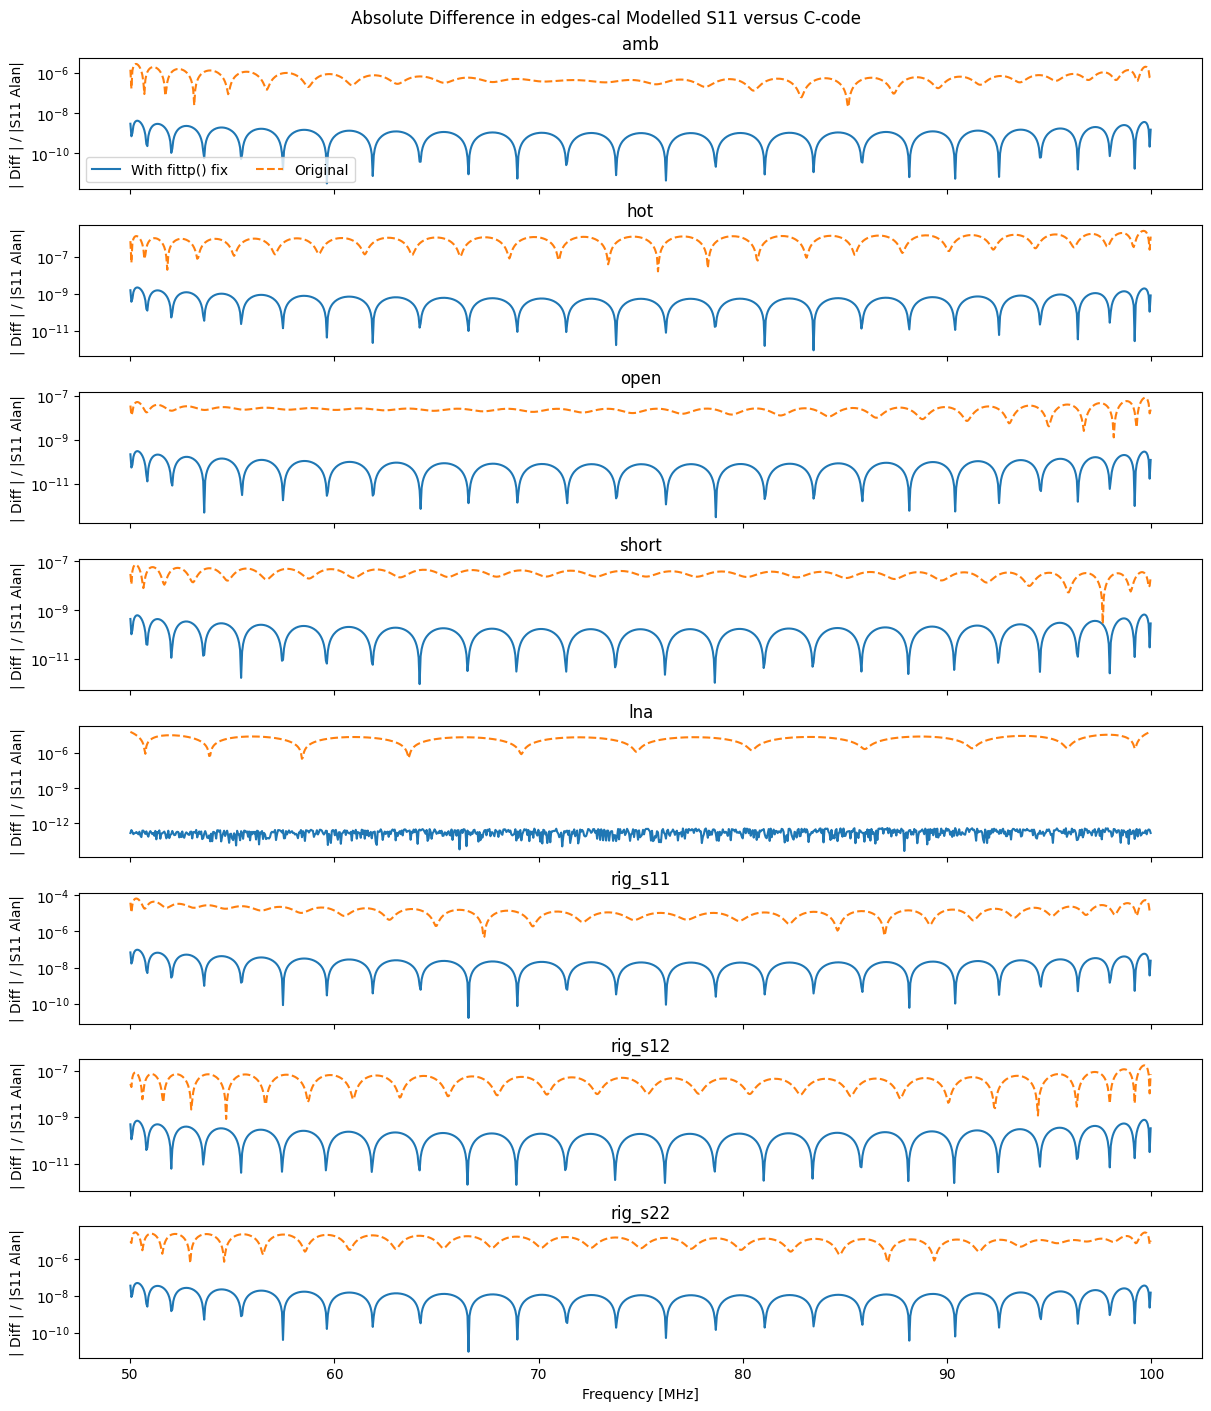

In [11]:
fig, ax = plt.subplots(
    len(alans11m.keys()), 1, sharex=True, constrained_layout=True, figsize=(12, 14)
)

for j, (case, _as11) in enumerate(alan_s11m_cases.items()):
    for i, load in enumerate(ours11m.keys()):
        us = ours11m[load].to_numpy()
        al = _as11[load].to_numpy()
        ax[i].plot(
            calfreq, np.abs(al - us) / np.abs(al), label=case, ls=["-", "--"][j % 2]
        )
        ax[i].set_title(load)
        ax[i].set_yscale("log")
        ax[i].set_ylabel("| Diff | / |S11 Alan|")

ax[0].legend(ncols=2)
ax[-1].set_xlabel("Frequency [MHz]")
fig.suptitle("Absolute Difference in edges-cal Modelled S11 versus C-code");

**Figure 1 |** Comparison of smoothed/modelled $S_{11}$ values for all loads, including receiver and semi-rigid cable, between `edges-cal` and the C-code. Each panel represents a different load, and the two colors/linestyles in each panel represent two different cases of the C-code: with and without the fix to `fittp()` (see above for description). These values are used *in memory* in both the C-code and `edges-cal`, so they are used at high precision (we write them out here with 16 decimals, so the differences look smooth). With the `fittp()` fix (blue solid) the relative errors are generally less than one part in $10^8$. 

### Check Spectrum Averaging

In [12]:
def read_all_avspec(direc: Path, withr: bool):
    spec = {}
    allfiles = direc.glob("spe_*r.txt") if withr else direc.glob("sp*.txt")
    
    for fl in allfiles:
        if withr:
            load = fl.name.split("_")[1][:-5]
        else:
            load = fl.stem[2:]
            
        s = read_spec_txt(fl)
        spec[load] = s.data.squeeze()
        freq = s.freqs
    return freq, spec

In [13]:
spfreq, alanspec = read_all_avspec(Path(f"{alandir}/H2Case"), withr=True)
spfreq, ourspec = read_all_avspec(outpath, withr=False)

In [14]:
alanspec.keys()

dict_keys(['short', 'load', 'open', 'hot'])

Text(0.5, 0.98, 'Raw spectra differences')

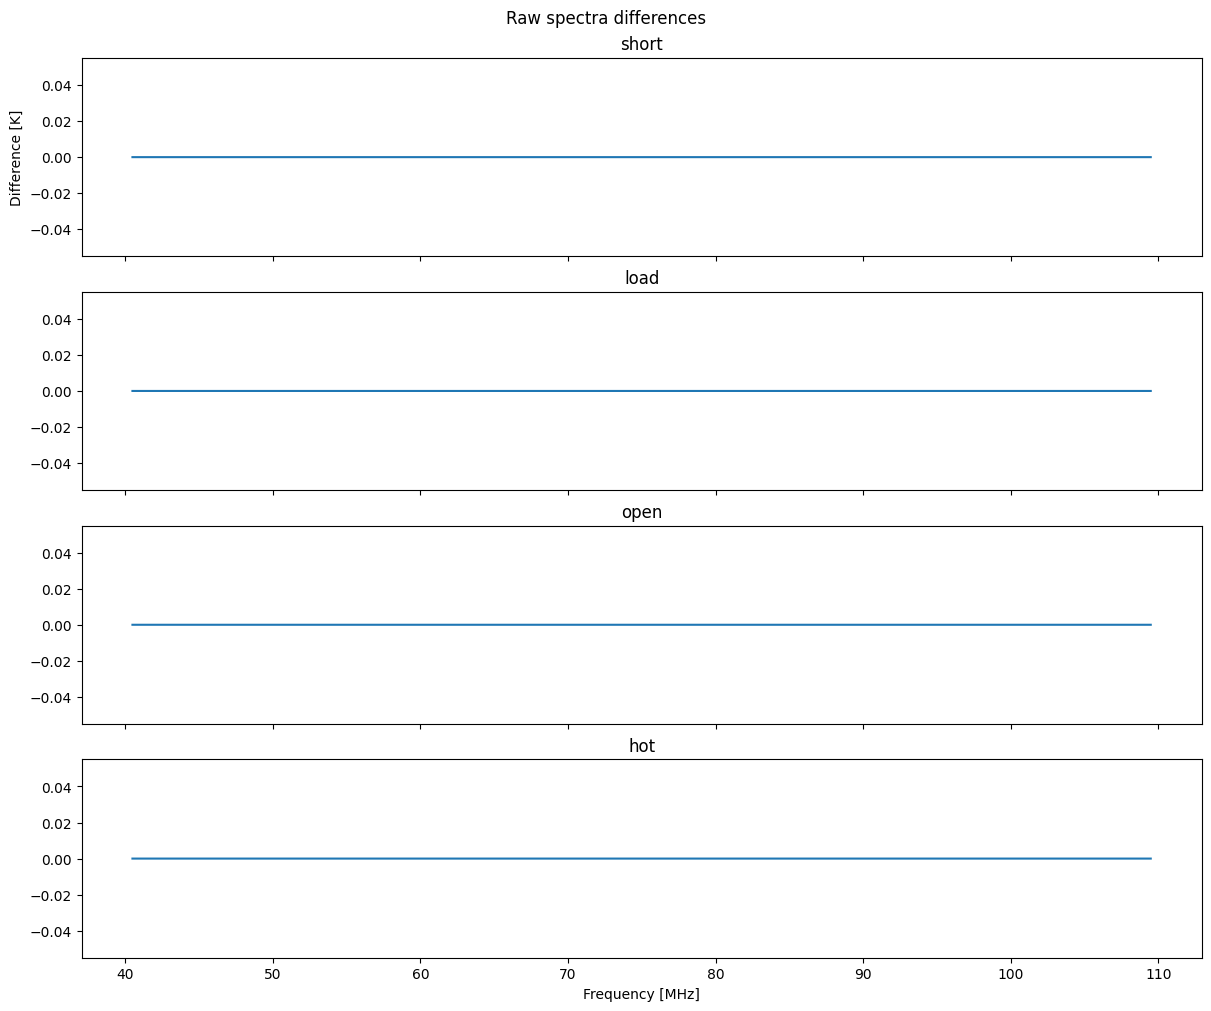

In [15]:
fig, ax = plt.subplots(
    len(alanspec), 1, sharex=True, constrained_layout=True, figsize=(12, 10)
)
for i, load in enumerate(alanspec):
    if load =='load':
        oload='ambient'
    else:
        oload = LOADMAP[load]
    ax[i].plot(spfreq[10:-10], alanspec[load][10:-10] - ourspec[oload][10:-10])
    ax[i].set_title(load)
    ax[0].set_ylabel("Difference [K]")

ax[-1].set_xlabel("Frequency [MHz]")
fig.suptitle("Raw spectra differences")

**Figure 2 |** Comparison of output averaged uncalibrated spectra from `acqplot7amoon` for each load. The differences here are exactly zero between the two pipelines. The precision of the files output is quite low: only six decimal places, so the exact correspondence here only indicates correspondence to this precision. However, since this data is only ever used after being written out and then read from these files (both in the C-code and in the `alancal` command), this ensures exact correspondence between the pipelines.

### Check Hot Load Loss

In [16]:
alans_hot_load_loss = np.genfromtxt(f"{alandir}/H2Case/hot_load_loss.txt")
our_hot_load_loss = np.genfromtxt(outpath / "hot_load_loss.txt")

Text(0.5, 1.0, 'Difference in hot load loss model')

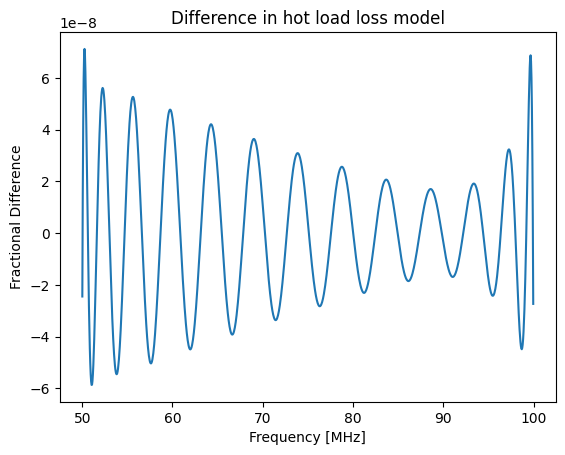

In [17]:
plt.plot(calfreq, our_hot_load_loss[:, 1] / alans_hot_load_loss[alanmask, 1] - 1)
plt.xlabel("Frequency [MHz]")
plt.ylabel("Fractional Difference")
plt.title("Difference in hot load loss model")

**Figure 3 |** Fractional difference in the hot load loss model.

### Check Calibration Coefficients

In [18]:
ourcal = read_specal(outpath / "specal.txt", t_load=acq.tload, t_load_ns=acq.tcal)

In [19]:
alancal_orig = read_specal(f"{alandir}/H2Case/specal.txt", t_load=acq.tload, t_load_ns=acq.tcal)

In [20]:
alancal_fitp = read_specal(f"{alandir}/H2Case-fittpfix/specal.txt", t_load=acq.tload, t_load_ns=acq.tcal)

In [21]:
alancal_cases = {
    "With fittp() fix": alancal_fitp,
    "Original": alancal_orig,
}

In [22]:
def plot_calcoeff_cases(cases, comp_case, fig=None, ax=None):
    if fig is None:
        fig, ax = plt.subplots(
            5,
            1,
            sharex=True,
            constrained_layout=True,
            figsize=(12, 15),
        )

    fields = ['Tsca', 'Toff', 'Tunc', 'Tcos', 'Tsin']
    for ic, (case, cal) in enumerate(cases.items()):
        j = 0

        for i, name in enumerate(fields):
            ax[j].plot(
                comp_case.freqs,
                np.abs(getattr(comp_case, name) - getattr(cal, name)),
                label=case,
                ls=["-", "--"][ic % 2],
            )

            # ax[j].set_yscale('log')
            ax[j].set_title(name)
            if name.startswith("T"):
                ax[j].set_ylabel("Difference [K]")
            else:
                ax[j].set_ylabel("Difference")
            j += 1

    ax[0].legend()
    ax[-1].set_xlabel("Frequency [MHz]")

    return fig, ax

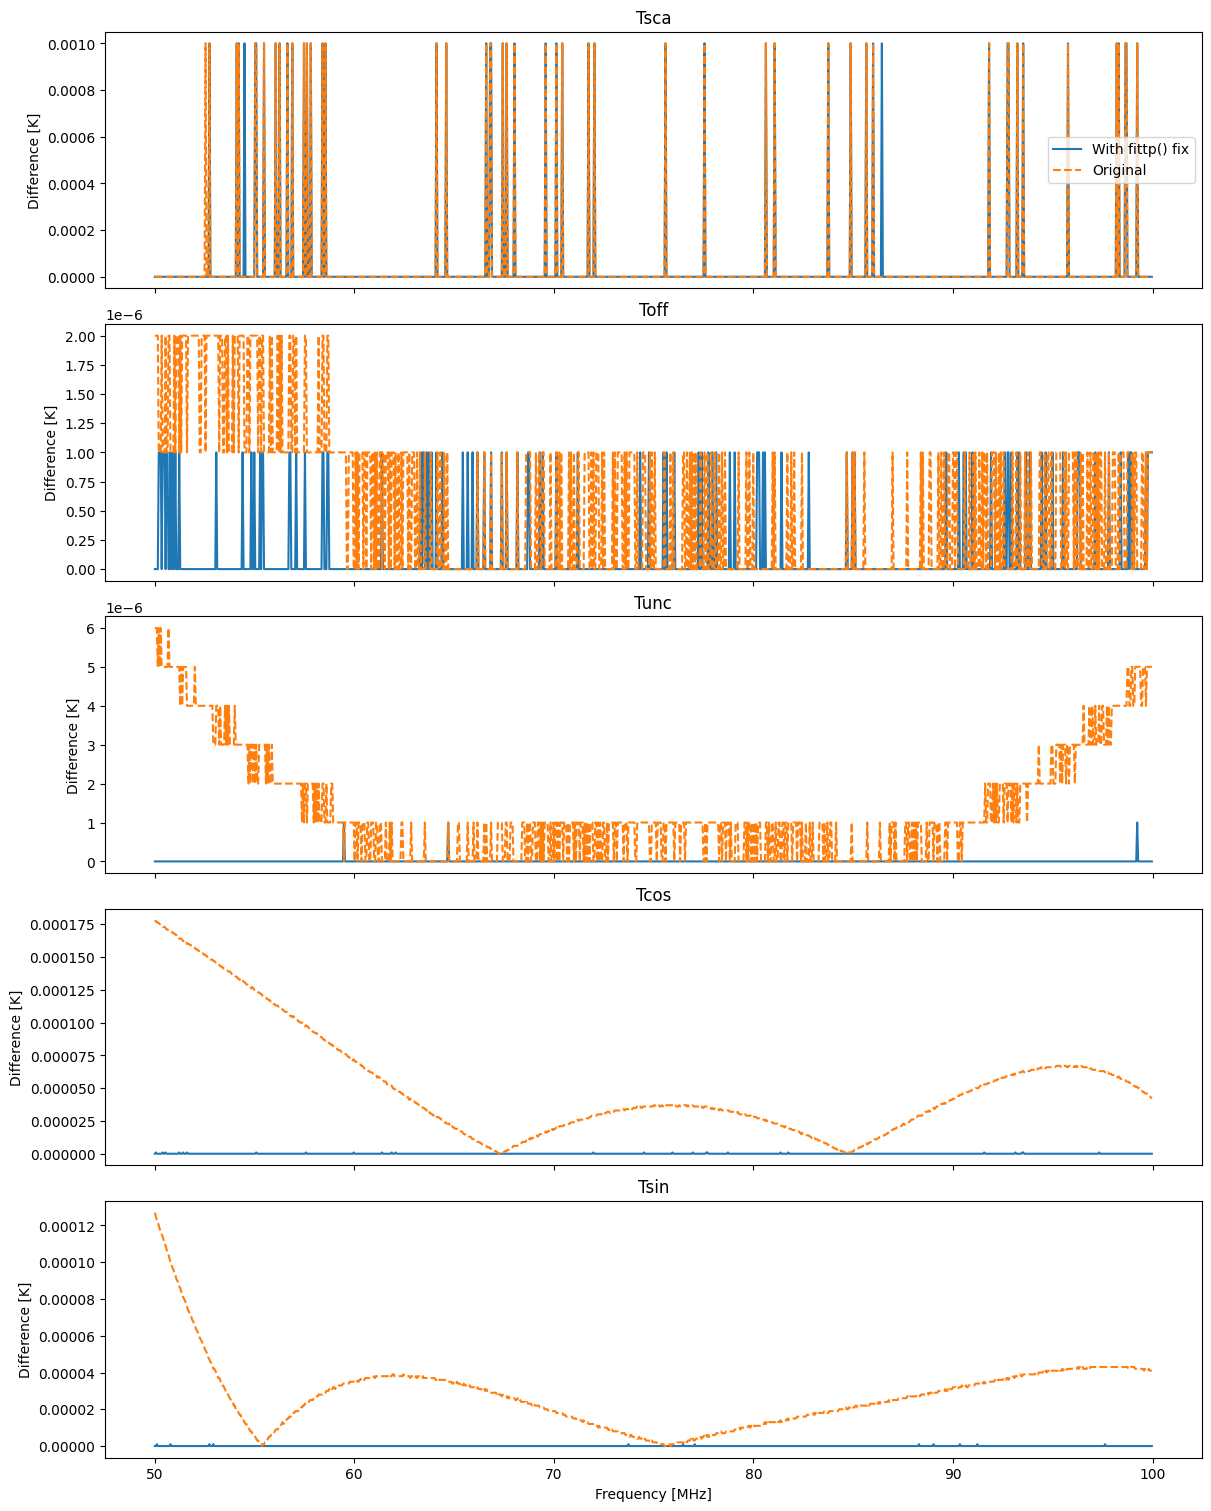

In [23]:
plot_calcoeff_cases(alancal_cases, ourcal);

**Figure 4 |** Absolute differences between calibration coefficients and LNA $S_{11}$, as saved in the `specal.txt` file from the `edges2k.c` pipeline. Different colors represent different cases of the C-code: with and without the fix to `fittp()`, as described above. With the fix (blue solid), the differences are always with $10^{-6}$, which is the precision of the output file. Without the fix (orange dashed), the noise-wave parameters $T_{\rm cos}$ and $T_{\rm sin}$ have larger differences, on the order of 0.1 mK. 

One thing that potentially should be noted is that the precision of the output `specal.txt` file, which is the file used for performing calibration on field data, is actually quite low, with just six decimal places. For $C_1$, which is a multiplicative gain, this translates to about 10 mK for sky temperatures of $10^4$ K. My suggestion would be to increase this precision by at least a couple of decimal places, to ensure it is well below the noise level.